# Analisis Pengaruh Teknik Preprocessing terhadap Klasifikasi Ginjal Normal dan Batu Ginjal Menggunakan Fitur Gray Level Co-occurrence Matrix (GLCM) serta Perbandingan Algoritma Support Vector Machine (SVM), Random Forest, dan K-Nearest Neighbor (KNN)
## Percobaan 1 — Preprocessing: Grayscale + Resize (2 Preprocessing)
### Nama Anggota
- Muhammad Andika Azkiya : F1D02410076
- Gusti Ayu Marsha Widyaswari : F1D02410007
- Ahmad Yadan Ulya Munaji : F1D02410100
- Revano Januar Adiguna Prawira : F1D02410146

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Import Library

### Fungsi
Cell ini mengimpor seluruh pustaka (*library*) yang dibutuhkan selama proses penelitian, mulai dari pengolahan citra, ekstraksi fitur tekstur menggunakan Gray Level Co-occurrence Matrix (GLCM), visualisasi data, hingga proses klasifikasi menggunakan algoritma Machine Learning.

Library yang digunakan meliputi:

- **OpenCV (cv2)** untuk pengolahan citra digital.
- **NumPy** untuk komputasi numerik dan manipulasi array.
- **Pandas** untuk pengelolaan data tabular.
- **Matplotlib** untuk visualisasi data.
- **Scikit-image** untuk pembentukan matriks GLCM dan ekstraksi fitur tekstur.
- **Scikit-learn** untuk pembagian data, normalisasi, pelatihan model, dan evaluasi klasifikasi.

### Analisis
Tahap import library merupakan langkah awal yang sangat penting karena seluruh proses penelitian bergantung pada fungsi-fungsi yang tersedia dalam library tersebut. Pemilihan library yang tepat memungkinkan proses pengolahan data menjadi lebih efisien, akurat, dan mudah direproduksi pada penelitian selanjutnya.

## Memuat Dataset dan Resize Citra

### Fungsi
Cell ini bertugas membaca seluruh citra ginjal dari dataset yang tersedia kemudian melakukan proses *resize* ke ukuran 256×256 piksel. Selain itu, label kelas dan nama file juga disimpan untuk digunakan pada tahap selanjutnya.

Proses resize dilakukan untuk menyeragamkan dimensi seluruh citra sehingga setiap gambar memiliki ukuran yang sama sebelum dilakukan ekstraksi fitur.

### Analisis
Ukuran citra yang berbeda-beda dapat menyebabkan ketidakkonsistenan dalam proses ekstraksi fitur. Oleh karena itu, proses resize dilakukan untuk menghasilkan representasi citra yang seragam. Ukuran 256×256 dipilih karena cukup besar untuk mempertahankan informasi tekstur penting namun tetap efisien dari sisi komputasi.

Output dari tahap ini berupa:
- Data citra hasil resize.
- Label kelas (Normal atau Batu Ginjal).
- Nama file citra.

In [2]:
def resize_image(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Assets'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (256, 256))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 648
Labels: ['Normal' 'kidneyStone']


## Visualisasi Distribusi Dataset

### Fungsi
Cell ini menampilkan distribusi jumlah citra pada masing-masing kelas menggunakan diagram batang (*bar chart*). Visualisasi ini digunakan untuk mengetahui komposisi dataset yang akan digunakan pada proses ekstraksi fitur GLCM dan klasifikasi.

### Analisis
Berdasarkan grafik distribusi dataset, diperoleh:

- Kelas **Normal** sebanyak **356 citra**
- Kelas **Kidney Stone** sebanyak **292 citra**

Sehingga total dataset yang digunakan dalam penelitian ini berjumlah **648 citra**.

Pemilihan jumlah data yang lebih banyak dilakukan karena pada percobaan awal menggunakan dataset yang lebih kecil, yaitu sekitar **100 citra untuk masing-masing kelas**, seluruh model klasifikasi mampu mencapai akurasi mendekati atau bahkan mencapai **100%**. Kondisi tersebut menunjukkan bahwa dataset terlalu mudah dipelajari oleh model sehingga perbedaan performa antar metode preprocessing maupun algoritma klasifikasi menjadi sulit diamati.

Oleh karena itu, jumlah data diperbesar agar variasi karakteristik citra yang dipelajari model menjadi lebih beragam. Dengan semakin banyak data yang digunakan, tingkat kompleksitas klasifikasi juga meningkat karena model harus mengenali lebih banyak variasi bentuk, tekstur, pencahayaan, dan karakteristik citra pada masing-masing kelas.

Meskipun jumlah data kelas Normal dan Kidney Stone tidak sama persis, perbedaannya masih relatif kecil sehingga distribusi dataset tetap dapat dianggap cukup seimbang. Kondisi ini memungkinkan model memperoleh representasi yang baik dari kedua kelas tanpa menimbulkan bias yang signifikan terhadap salah satu kelas.

Penggunaan dataset yang lebih besar diharapkan dapat menghasilkan evaluasi yang lebih realistis dan mampu menunjukkan pengaruh teknik preprocessing terhadap performa klasifikasi. Dengan demikian, perbandingan antara Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dapat dilakukan secara lebih objektif karena model diuji pada data yang lebih beragam dan menantang dibandingkan percobaan awal.

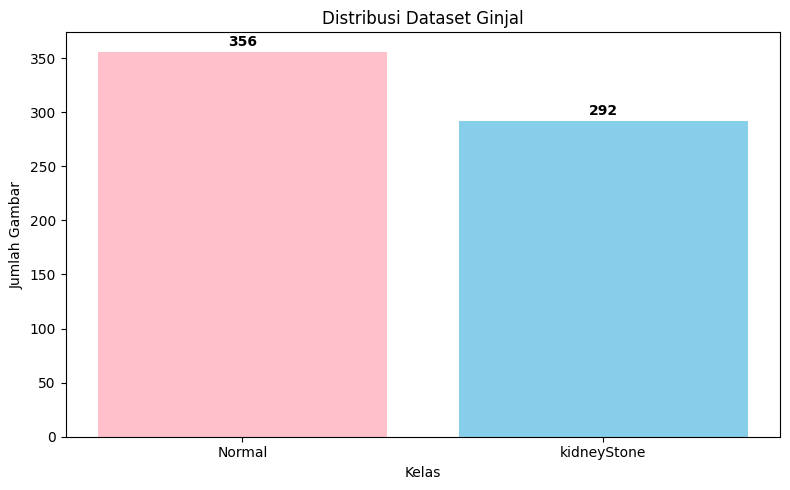

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['pink', 'skyblue'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Ginjal')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisasi Sampel Citra Dataset

### Fungsi
Cell ini menampilkan beberapa contoh citra dari masing-masing kelas dataset untuk memberikan gambaran visual mengenai karakteristik data yang digunakan dalam penelitian.

### Analisis
Visualisasi sampel citra membantu peneliti melakukan inspeksi awal terhadap kualitas dataset. Melalui tahap ini dapat diamati perbedaan pola visual antara ginjal normal dan ginjal yang mengandung batu ginjal.

Selain itu, tahap ini juga berguna untuk memastikan bahwa proses pembacaan dan resize citra telah berjalan dengan benar sebelum dilakukan tahap preprocessing lanjutan.

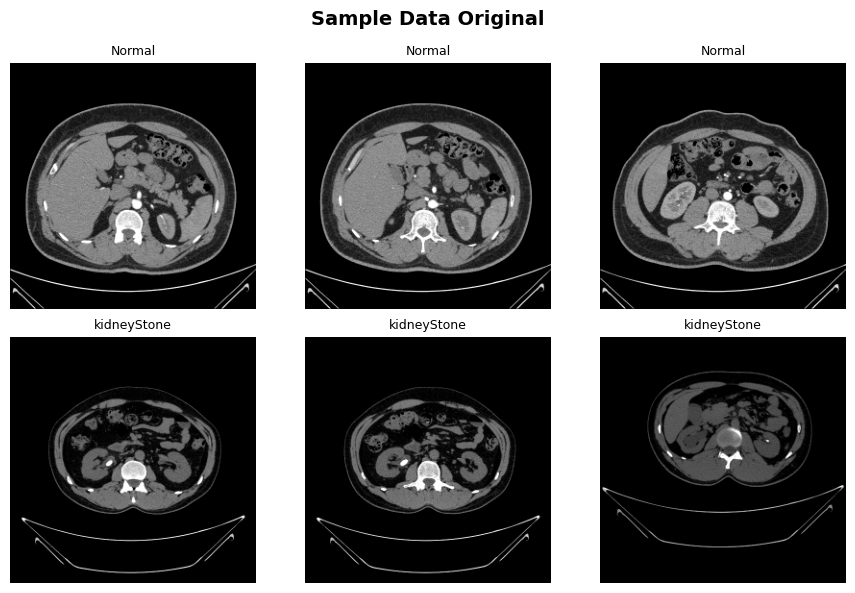

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Konversi Citra ke Grayscale

### Fungsi
Cell ini mengubah seluruh citra berwarna (RGB/BGR) menjadi citra grayscale menggunakan fungsi `cv.cvtColor()` dari OpenCV.

Proses grayscale mengubah citra yang semula terdiri dari tiga kanal warna (Red, Green, Blue) menjadi satu kanal intensitas keabuan (gray level).

### Alasan Pemilihan Preprocessing
Metode ekstraksi fitur Gray Level Co-occurrence Matrix (GLCM) bekerja berdasarkan hubungan tingkat keabuan antar piksel. Oleh karena itu, informasi warna tidak diperlukan dalam proses ekstraksi fitur.

Penggunaan grayscale dipilih karena mampu menyederhanakan representasi citra tanpa menghilangkan informasi tekstur yang menjadi fokus utama penelitian.

### Analisis Hasil
Sebelum konversi grayscale, setiap piksel memiliki tiga nilai intensitas warna. Setelah proses grayscale dilakukan, setiap piksel hanya memiliki satu nilai intensitas keabuan dengan rentang 0–255.

Dampak dari proses ini antara lain:

- Mengurangi dimensi data hingga sekitar 66%.
- Mempercepat proses komputasi.
- Menghilangkan variasi warna yang tidak relevan.
- Memfokuskan analisis pada pola tekstur jaringan ginjal.

Karena batu ginjal dan jaringan ginjal normal memiliki karakteristik tekstur yang berbeda, informasi tingkat keabuan dianggap lebih penting dibandingkan informasi warna.

Output dari tahap ini berupa kumpulan citra grayscale yang siap digunakan pada proses pembentukan matriks GLCM.

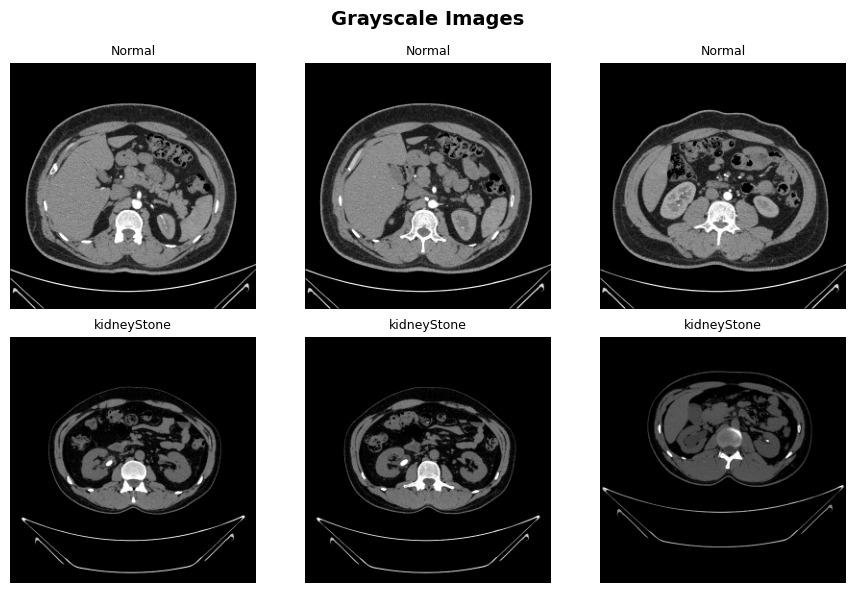

In [5]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Definisi Fungsi GLCM dan Fitur Tekstur

### Fungsi
Cell ini mendefinisikan fungsi pembentukan Gray Level Co-occurrence Matrix (GLCM) serta fungsi perhitungan fitur tekstur yang akan digunakan sebagai atribut klasifikasi.

Fitur yang dihitung meliputi:

- Contrast
- Dissimilarity
- Homogeneity
- Energy
- Correlation
- ASM

### Alasan Pemilihan Metode GLCM
GLCM merupakan salah satu metode ekstraksi fitur tekstur yang paling banyak digunakan pada citra medis karena mampu merepresentasikan hubungan spasial antar piksel.

Berbeda dengan metode statistik sederhana yang hanya melihat distribusi intensitas piksel, GLCM memperhatikan keterkaitan antar piksel sehingga mampu menggambarkan pola tekstur dengan lebih baik.

### Analisis Hasil
Setiap fitur memiliki interpretasi yang berbeda:

**Contrast**
Mengukur tingkat variasi intensitas piksel.

Nilai tinggi menunjukkan tekstur kasar dan perbedaan intensitas yang besar.

**Dissimilarity**
Mengukur tingkat ketidakmiripan antar piksel yang berdekatan.

Semakin tinggi nilainya maka tekstur semakin kompleks.

**Homogeneity**
Mengukur keseragaman distribusi intensitas piksel.

Semakin tinggi nilainya menunjukkan tekstur semakin halus.

**Energy**
Mengukur keteraturan pola tekstur.

Nilai tinggi menunjukkan pola yang lebih terstruktur.

**Correlation**
Mengukur hubungan linear antar piksel yang berdekatan.

**ASM (Angular Second Moment)**
Mengukur keseragaman distribusi probabilitas pada matriks GLCM.

Kombinasi keenam fitur tersebut diharapkan mampu merepresentasikan perbedaan tekstur antara ginjal normal dan ginjal yang mengandung batu.

## Pembentukan Matriks GLCM pada Berbagai Sudut

### Fungsi
Cell ini membentuk matriks GLCM menggunakan empat orientasi sudut, yaitu:

- 0°
- 45°
- 90°
- 135°

### Alasan Penggunaan Empat Sudut
Tekstur pada citra medis tidak selalu memiliki pola yang sama pada setiap arah.

Penggunaan beberapa orientasi sudut bertujuan untuk menangkap karakteristik tekstur secara lebih menyeluruh.

### Analisis Hasil
Setiap sudut menghasilkan representasi hubungan spasial piksel yang berbeda.

- 0° menggambarkan hubungan horizontal.
- 45° menggambarkan hubungan diagonal kanan atas.
- 90° menggambarkan hubungan vertikal.
- 135° menggambarkan hubungan diagonal kiri atas.

Dengan menggunakan empat orientasi tersebut, informasi tekstur yang diperoleh menjadi lebih lengkap dibandingkan hanya menggunakan satu orientasi saja.

Hasil tahap ini berupa empat matriks GLCM untuk setiap citra yang selanjutnya digunakan untuk menghitung fitur tekstur.

In [7]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(img_grey)):
    D0 = glcm(img_grey[i], 0)
    D45 = glcm(img_grey[i], 45)
    D90 = glcm(img_grey[i], 90)
    D135 = glcm(img_grey[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 648 images


## Ekstraksi Fitur Tekstur GLCM

### Fungsi
Cell ini melakukan ekstraksi fitur tekstur dari seluruh matriks GLCM yang telah dibentuk sebelumnya.

Untuk setiap sudut orientasi akan dihitung:

- Contrast
- Dissimilarity
- Homogeneity
- Energy
- Correlation
- ASM

### Analisis
Tahap ekstraksi fitur bertujuan mengubah informasi citra menjadi data numerik yang dapat diproses oleh algoritma Machine Learning.

Semakin representatif fitur yang diperoleh, semakin baik kemampuan model dalam mengenali perbedaan antara ginjal normal dan ginjal batu.

Output dari tahap ini berupa sekumpulan nilai fitur tekstur yang mewakili karakteristik setiap citra.

In [8]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(img_grey)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


## Pembentukan Dataset Fitur GLCM

### Fungsi
Cell ini menyusun seluruh fitur hasil ekstraksi Gray Level Co-occurrence Matrix (GLCM) ke dalam sebuah DataFrame menggunakan library Pandas.

Setiap baris merepresentasikan satu citra ginjal, sedangkan setiap kolom merepresentasikan fitur tekstur yang diperoleh dari proses ekstraksi GLCM pada berbagai orientasi sudut.

Dataset yang terbentuk terdiri dari informasi nama file, label kelas, serta fitur-fitur tekstur hasil ekstraksi GLCM yang akan digunakan sebagai masukan pada proses klasifikasi.

### Analisis

Hasil ekstraksi menghasilkan dataset fitur tekstur yang terdiri dari citra kelas Normal dan Kidney Stone. Dataset ini merupakan hasil transformasi citra grayscale menjadi representasi numerik yang dapat diproses oleh algoritma Machine Learning.

Pada preprocessing pertama, citra hanya melalui proses Resize dan Grayscale tanpa adanya peningkatan kualitas citra tambahan. Oleh karena itu fitur yang diperoleh merepresentasikan karakteristik tekstur asli dari citra ginjal.

Perbedaan nilai fitur yang muncul pada setiap citra menunjukkan bahwa metode GLCM mampu menangkap variasi pola tekstur antara ginjal normal dan ginjal yang mengandung batu. Variasi tersebut tercermin pada nilai Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, dan Correlation yang berbeda pada setiap sampel.

Dataset fitur yang terbentuk pada tahap ini menjadi dasar awal untuk mengetahui sejauh mana tekstur asli citra dapat digunakan dalam membedakan kedua kelas tanpa bantuan teknik peningkatan kualitas citra lainnya.

Output dari tahap ini berupa dataset fitur GLCM yang siap digunakan untuk proses seleksi fitur, normalisasi, dan klasifikasi.

In [9]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1.jpg,Normal,359.006250,840.256917,665.517310,808.456009,0.532037,0.516415,0.523642,0.515998,...,0.223670,0.220494,0.476571,0.469046,0.472938,0.469567,0.953657,0.891676,0.914091,0.895776
1,10.jpg,Normal,367.601700,845.811411,660.941299,811.046136,0.533845,0.518310,0.528561,0.519161,...,0.227221,0.224182,0.480432,0.472648,0.476677,0.473478,0.952041,0.889802,0.913772,0.894332
2,100.jpg,Normal,337.337408,804.144129,633.323683,751.466605,0.563605,0.545967,0.555141,0.546245,...,0.258676,0.255437,0.512650,0.504776,0.508602,0.505408,0.951055,0.883537,0.908114,0.891166
3,11.jpg,Normal,366.397978,842.702115,660.965947,811.618747,0.533739,0.519209,0.528099,0.519336,...,0.227369,0.224299,0.480617,0.472988,0.476833,0.473602,0.952284,0.890406,0.913924,0.894448
4,12.jpg,Normal,363.356281,840.847336,660.434161,808.384314,0.533704,0.518569,0.528646,0.519696,...,0.227633,0.224606,0.480910,0.473311,0.477109,0.473926,0.952793,0.890908,0.914198,0.895120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Stone- (515).jpg,kidneyStone,225.496278,648.382176,557.950092,665.000246,0.576292,0.555866,0.564369,0.556078,...,0.256487,0.252862,0.510484,0.503393,0.506445,0.502854,0.955205,0.871417,0.889161,0.868121
644,Stone- (516).jpg,kidneyStone,225.796186,647.979223,559.786520,668.336809,0.574947,0.556493,0.564077,0.555679,...,0.255930,0.252138,0.509841,0.502657,0.505895,0.502133,0.955040,0.871196,0.888535,0.867150
645,Stone- (517).jpg,kidneyStone,228.205254,648.973810,563.499311,676.506728,0.574315,0.555570,0.562900,0.555201,...,0.255463,0.251705,0.509488,0.502301,0.505433,0.501702,0.954738,0.871505,0.888235,0.866053
646,Stone- (518).jpg,kidneyStone,231.493306,651.834310,567.334758,685.216947,0.574713,0.554884,0.563016,0.553791,...,0.254800,0.250965,0.508819,0.501672,0.504777,0.500964,0.954453,0.871970,0.888371,0.865413


## Seleksi Fitur Menggunakan Correlation Matrix

### Fungsi
Cell ini melakukan proses seleksi fitur menggunakan metode Correlation Matrix untuk mengidentifikasi dan menghapus fitur-fitur yang memiliki korelasi sangat tinggi.

Fitur yang memiliki nilai korelasi di atas ambang batas yang ditentukan dianggap membawa informasi yang serupa sehingga salah satunya dapat dihapus untuk mengurangi redundansi data.

### Hasil Seleksi Fitur

Berdasarkan proses seleksi diperoleh:

- Jumlah fitur sebelum seleksi : **28 fitur**
- Jumlah fitur setelah seleksi : **10 fitur**
- Jumlah fitur yang dihapus : **18 fitur**

Fitur yang terpilih adalah:

- Contrast0
- Contrast45
- Contrast90
- Homogeneity0
- Dissimilarity0
- Dissimilarity45
- Dissimilarity90
- Entropy0
- Correlation0
- Correlation45

### Alasan Penggunaan Correlation Matrix

Pada proses ekstraksi GLCM, setiap fitur dihitung pada beberapa orientasi sudut sehingga beberapa fitur dapat memiliki hubungan yang sangat kuat satu sama lain. Kondisi ini menyebabkan sebagian fitur membawa informasi yang hampir sama.

Seleksi fitur dilakukan untuk mengurangi redundansi informasi dan mempertahankan fitur yang paling representatif terhadap karakteristik tekstur citra.

### Analisis Hasil

Hasil seleksi menunjukkan bahwa dari 28 fitur awal hanya 10 fitur yang dipertahankan. Hal ini menunjukkan bahwa sebagian besar fitur memiliki korelasi yang tinggi sehingga informasi yang dibawanya dapat diwakili oleh fitur lain.

Pada preprocessing pertama yang hanya menggunakan Resize dan Grayscale, fitur yang bertahan terdiri dari Contrast, Homogeneity, Dissimilarity, Entropy, dan Correlation. Kombinasi fitur tersebut menunjukkan bahwa perbedaan antara ginjal normal dan ginjal batu masih dipengaruhi oleh berbagai karakteristik tekstur secara bersamaan.

Fitur Contrast menggambarkan tingkat variasi intensitas piksel, Dissimilarity menggambarkan tingkat ketidakmiripan antar piksel, Homogeneity menunjukkan tingkat keseragaman tekstur, Entropy menggambarkan kompleksitas pola tekstur, sedangkan Correlation menunjukkan hubungan spasial antar piksel.

Hasil ini menunjukkan bahwa tanpa penambahan teknik peningkatan kualitas citra, informasi tekstur yang digunakan untuk membedakan kedua kelas masih tersebar pada berbagai jenis fitur GLCM. Oleh karena itu, beberapa kelompok fitur tetap dipertahankan setelah proses seleksi karena masing-masing masih memberikan informasi yang relevan terhadap proses klasifikasi.

Pengurangan jumlah fitur dari 28 menjadi 10 fitur diharapkan mampu mengurangi kompleksitas model tanpa menghilangkan informasi penting yang diperlukan untuk membedakan citra ginjal normal dan ginjal batu.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 10
Fitur terpilih: ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'Entropy0', 'Correlation0', 'Correlation45']


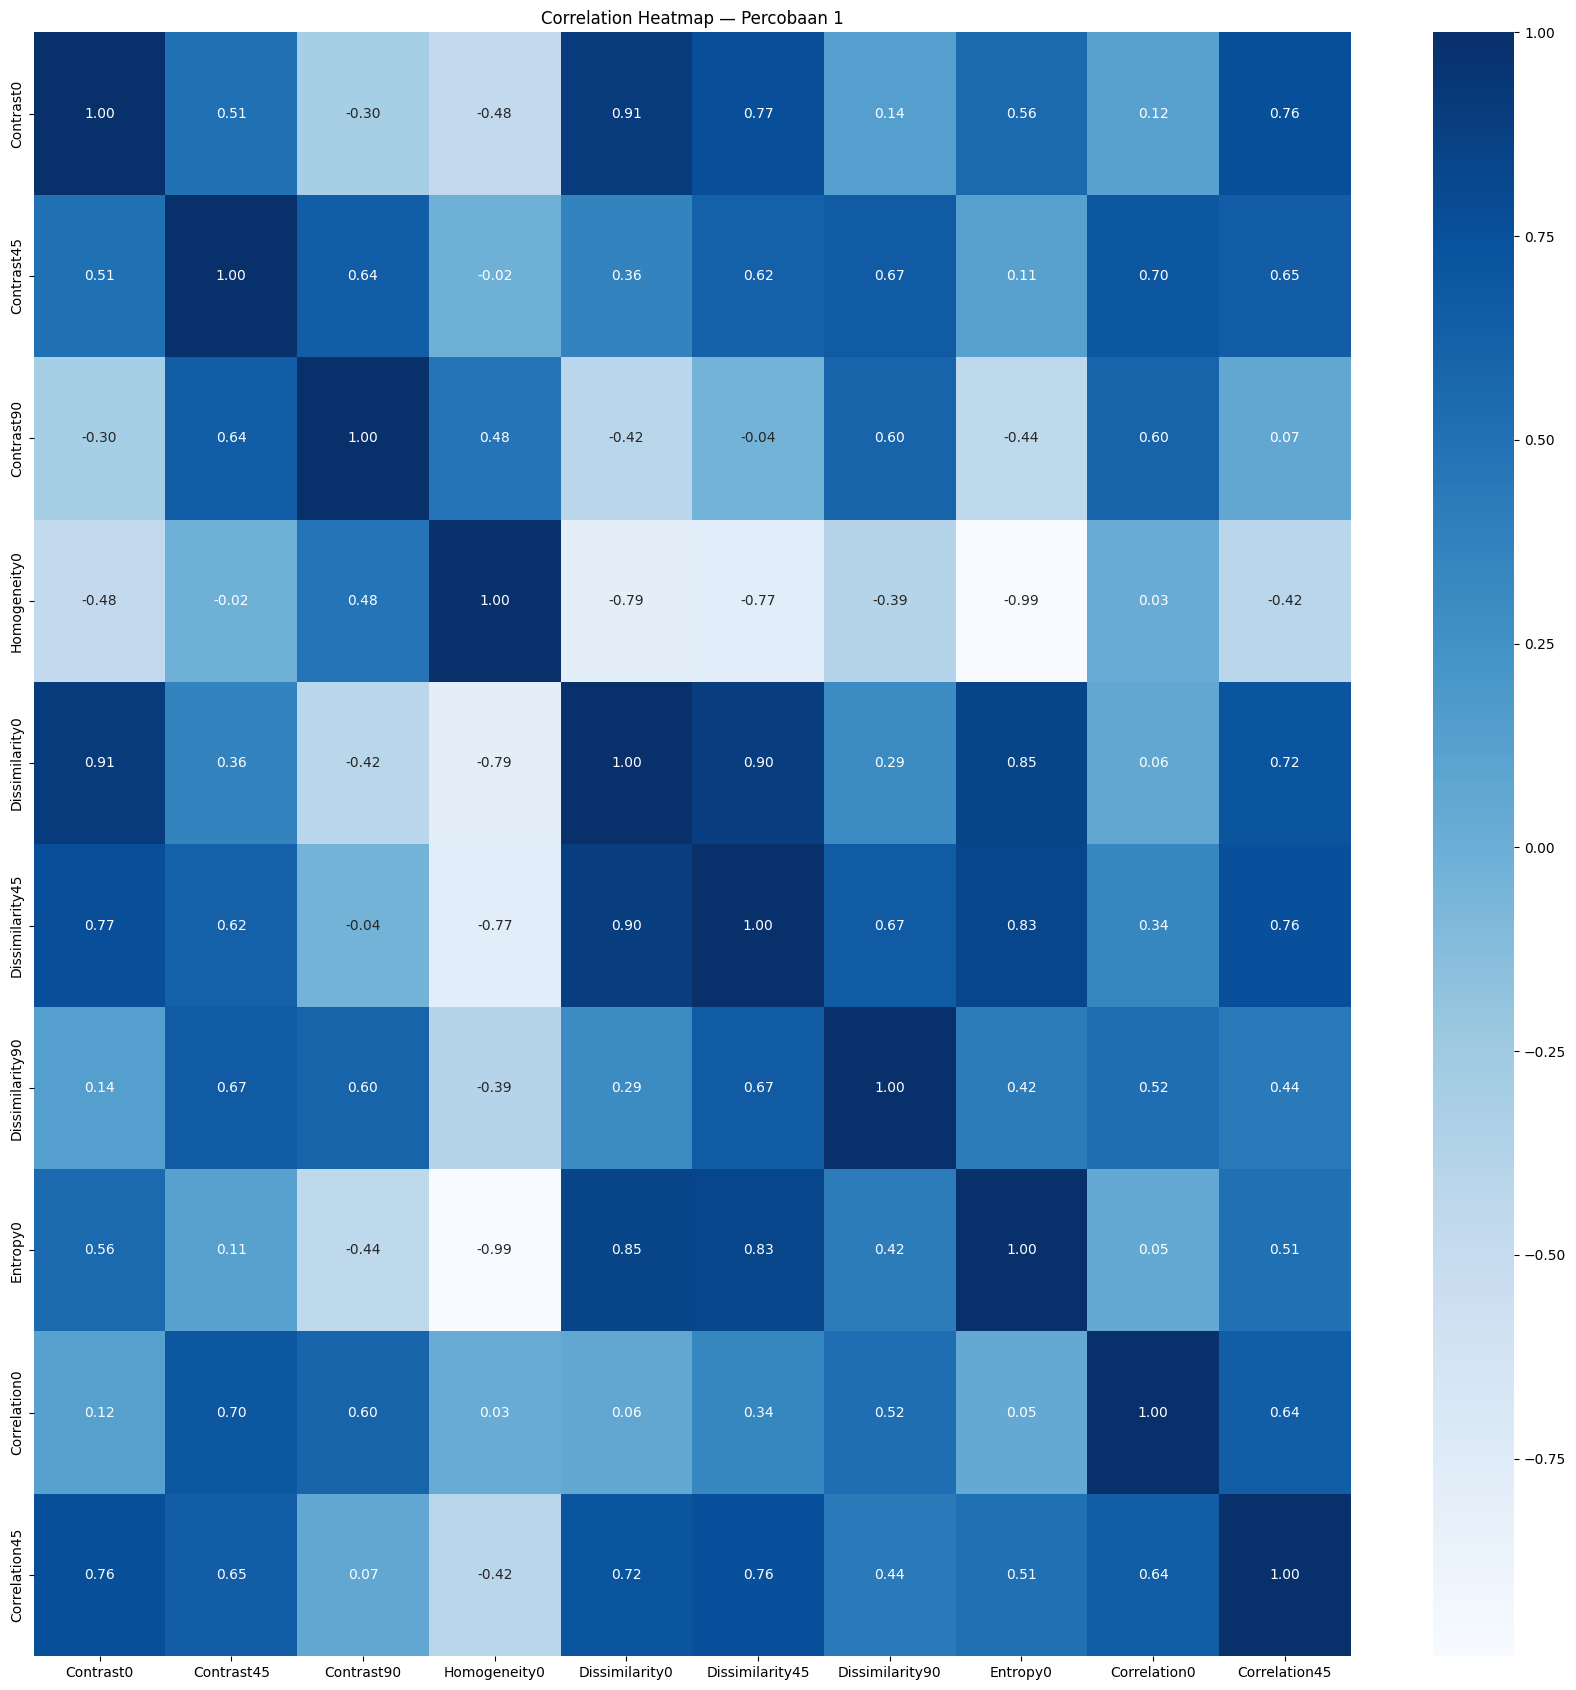

In [10]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 1')
plt.tight_layout()
plt.show()

## Pembagian Data Training dan Testing

### Fungsi
Cell ini membagi dataset fitur hasil seleksi menjadi data training dan data testing menggunakan fungsi `train_test_split()` dari library Scikit-Learn.

Pembagian dilakukan dengan parameter:

```python
test_size = 0.2
```

yang berarti 20% data digunakan sebagai data testing dan sisanya 80% digunakan sebagai data training.

### Hasil Pembagian Data

Berdasarkan proses pembagian data diperoleh:

- Data Training : **518 data**
- Data Testing : **130 data**
- Total Data : **648 data**

Dengan jumlah fitur yang digunakan setelah proses seleksi sebanyak **10 fitur**.

Sehingga ukuran dataset yang dihasilkan adalah:

- Training set : **(518, 10)**
- Testing set : **(130, 10)**

### Analisis

Data training digunakan untuk melatih model agar mampu mempelajari pola hubungan antara fitur tekstur GLCM dengan kelas citra ginjal. Sementara itu, data testing digunakan untuk mengevaluasi performa model pada data yang tidak ikut digunakan selama proses pelatihan.

Penggunaan proporsi 80:20 dipilih karena merupakan salah satu rasio yang umum digunakan dalam penelitian Machine Learning. Proporsi ini memberikan jumlah data yang cukup besar untuk proses pelatihan sekaligus tetap menyediakan data yang memadai untuk proses evaluasi.

Dari total 648 data yang tersedia, sebanyak 518 data digunakan untuk membangun model klasifikasi, sedangkan 130 data digunakan untuk menguji kemampuan model dalam melakukan prediksi terhadap data baru.

Pembagian data dilakukan secara acak menggunakan parameter `random_state=42` sehingga hasil pembagian dapat direproduksi kembali pada percobaan selanjutnya. Penggunaan nilai random state yang tetap juga memastikan bahwa seluruh algoritma klasifikasi diuji menggunakan data training dan testing yang sama sehingga perbandingan performa model dapat dilakukan secara lebih objektif.

Tahap ini sangat penting karena memungkinkan pengukuran kemampuan generalisasi model, yaitu kemampuan model dalam mengenali pola pada data yang belum pernah dilihat sebelumnya.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (518, 10)
Testing set: (130, 10)


In [12]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Normalisasi Data Fitur

### Fungsi
Cell ini melakukan normalisasi data menggunakan metode **Z-Score Standardization** atau **Standard Scaling**.

Normalisasi dilakukan dengan rumus:

\[
Z = \frac{x-\mu}{\sigma}
\]

dengan:

- \(x\) = nilai fitur
- \(\mu\) = rata-rata fitur pada data training
- \(\sigma\) = standar deviasi fitur pada data training

Pada proses ini, nilai rata-rata dan standar deviasi dihitung dari data training, kemudian digunakan untuk menormalisasi data training maupun data testing.

### Alasan Dilakukan Normalisasi

Fitur-fitur hasil ekstraksi GLCM memiliki rentang nilai yang berbeda-beda.

Sebagai contoh:

- Contrast dapat memiliki nilai hingga ribuan.
- Correlation umumnya berada pada rentang 0 hingga 1.
- Homogeneity biasanya memiliki nilai sekitar 0,4 hingga 0,8.

Perbedaan skala tersebut dapat menyebabkan fitur dengan nilai yang lebih besar mendominasi proses pembelajaran model.

Oleh karena itu dilakukan normalisasi agar seluruh fitur berada pada skala yang sebanding.

### Analisis

Setelah proses normalisasi, setiap fitur memiliki:

- Rata-rata (mean) mendekati 0.
- Standar deviasi (standard deviation) mendekati 1.

Proses ini membuat seluruh fitur memiliki kontribusi yang lebih seimbang selama proses klasifikasi.

Normalisasi menjadi sangat penting terutama pada algoritma:

- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

karena kedua algoritma tersebut menggunakan perhitungan jarak atau posisi data dalam ruang fitur. Apabila terdapat fitur dengan rentang nilai yang jauh lebih besar dibandingkan fitur lainnya, maka fitur tersebut dapat mendominasi proses klasifikasi dan menyebabkan hasil prediksi menjadi kurang optimal.

Pada penelitian ini, nilai rata-rata dan standar deviasi dihitung dari data training kemudian digunakan untuk menormalisasi data training dan data testing. Pendekatan ini dilakukan untuk menghindari terjadinya *data leakage*, yaitu kondisi ketika informasi dari data testing ikut digunakan selama proses pelatihan model.

Dengan demikian, proses evaluasi model dapat dilakukan secara lebih objektif dan mencerminkan kemampuan model dalam menghadapi data baru yang belum pernah dilihat sebelumnya.

In [13]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Inisialisasi Model Klasifikasi dan Fungsi Evaluasi

### Fungsi

Cell ini mendefinisikan fungsi evaluasi serta menginisialisasi tiga algoritma klasifikasi yang akan digunakan dalam penelitian, yaitu:

1. Random Forest (RF)
2. Support Vector Machine (SVM)
3. K-Nearest Neighbor (KNN)

Selain itu, dibuat fungsi `generateClassificationReport()` untuk menampilkan hasil evaluasi model berupa:

- Precision
- Recall
- F1-Score
- Accuracy

Hasil evaluasi tersebut digunakan untuk membandingkan performa masing-masing algoritma dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

### Alasan Pemilihan Algoritma

Ketiga algoritma dipilih karena memiliki pendekatan klasifikasi yang berbeda sehingga dapat memberikan perbandingan performa yang lebih komprehensif terhadap fitur tekstur GLCM yang digunakan.

- Random Forest mewakili metode berbasis ensemble learning.
- SVM mewakili metode berbasis hyperplane.
- KNN mewakili metode berbasis kedekatan jarak antar data.

Dengan menggunakan ketiga algoritma tersebut, dapat diketahui algoritma mana yang paling efektif dalam mengenali pola tekstur citra ginjal.

### Parameter Model

#### Random Forest

```python
RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
```

Parameter `n_estimators=100` menunjukkan bahwa model membangun 100 pohon keputusan (*decision tree*) yang kemudian digabungkan melalui mekanisme voting untuk menghasilkan keputusan akhir.

Jumlah 100 pohon dipilih karena secara umum mampu memberikan keseimbangan antara akurasi dan waktu komputasi. Jumlah pohon yang terlalu sedikit dapat menyebabkan model kurang stabil, sedangkan jumlah yang terlalu banyak dapat meningkatkan waktu pelatihan tanpa peningkatan performa yang signifikan.

Parameter `random_state=42` digunakan untuk memastikan proses pembentukan model dapat direproduksi kembali pada percobaan berikutnya. Dengan nilai random state yang tetap, hasil eksperimen akan tetap konsisten setiap kali kode dijalankan.

#### Support Vector Machine (SVM)

```python
SVC(
    kernel='rbf',
    random_state=42
)
```

Kernel `rbf` (*Radial Basis Function*) dipilih karena mampu menangani hubungan non-linear antar fitur. Pada data tekstur GLCM, batas pemisah antara kelas Normal dan Kidney Stone belum tentu berbentuk linear sehingga kernel RBF sering memberikan performa yang lebih baik dibandingkan kernel linear.

Parameter `random_state=42` digunakan untuk menjaga konsistensi hasil eksperimen.

#### K-Nearest Neighbor (KNN)

```python
KNeighborsClassifier(
    n_neighbors=5
)
```

Parameter `n_neighbors=5` menunjukkan bahwa proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari suatu data.

Nilai K = 5 dipilih karena merupakan nilai yang umum digunakan dan mampu memberikan keseimbangan antara sensitivitas terhadap noise dan kemampuan generalisasi model. Nilai K yang terlalu kecil dapat menyebabkan model terlalu sensitif terhadap data tertentu, sedangkan nilai K yang terlalu besar dapat menyebabkan batas antar kelas menjadi kurang jelas.

### Analisis

Tahap ini merupakan langkah awal sebelum proses pelatihan model dilakukan. Parameter yang digunakan pada masing-masing algoritma dipilih berdasarkan konfigurasi yang umum digunakan dalam penelitian klasifikasi serta mampu memberikan performa yang stabil tanpa memerlukan proses optimasi parameter yang kompleks.

Dengan menggunakan konfigurasi yang sama pada seluruh percobaan preprocessing, perbedaan performa yang diperoleh nantinya lebih mencerminkan pengaruh teknik preprocessing dan kualitas fitur yang dihasilkan dibandingkan pengaruh perubahan parameter model.

Oleh karena itu, hasil evaluasi yang diperoleh dapat digunakan sebagai dasar yang lebih objektif untuk membandingkan performa Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

## Pelatihan dan Pengujian Model Random Forest

### Fungsi

Cell ini digunakan untuk melatih model Random Forest menggunakan data training yang telah melalui proses preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi.

Setelah proses pelatihan selesai, model digunakan untuk melakukan prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

Evaluasi dilakukan untuk mengetahui kemampuan model dalam membedakan citra ginjal Normal dan Kidney Stone.

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|----------|----------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **518 data**, terdiri dari:

- 278 citra Normal
- 240 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|----------|----------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **130 data**, terdiri dari:

- 78 citra Normal
- 52 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model Random Forest berhasil mengklasifikasikan seluruh data training dan data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak terdapat kesalahan klasifikasi pada kedua kelas, baik kelas Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur GLCM yang digunakan mampu merepresentasikan karakteristik kedua kelas dengan sangat baik sehingga model dapat membangun batas keputusan yang jelas.

Kesamaan performa antara data training dan data testing juga menunjukkan bahwa model tidak mengalami penurunan performa ketika dihadapkan pada data yang belum pernah dilihat sebelumnya. Dengan kata lain, tidak ditemukan indikasi overfitting yang signifikan berdasarkan hasil evaluasi yang diperoleh.

Tingginya performa model dapat disebabkan oleh beberapa faktor, antara lain:

- Kualitas fitur GLCM yang mampu menangkap perbedaan tekstur antara ginjal normal dan batu ginjal.
- Proses seleksi fitur yang berhasil mempertahankan fitur-fitur paling relevan.
- Distribusi data yang relatif seimbang antara kedua kelas.
- Kemampuan Random Forest dalam menggabungkan banyak pohon keputusan untuk menghasilkan prediksi yang stabil.

Meskipun hasil yang diperoleh sangat baik, nilai akurasi 100% juga perlu dianalisis secara hati-hati karena dapat mengindikasikan bahwa karakteristik kedua kelas pada dataset cukup mudah dipisahkan oleh model. Oleh karena itu, hasil Random Forest selanjutnya akan dibandingkan dengan algoritma Support Vector Machine (SVM) dan K-Nearest Neighbor (KNN) untuk mengetahui apakah pola yang sama juga terjadi pada algoritma lainnya.

In [14]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       278
 kidneyStone       1.00      1.00      1.00       240

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        78
 kidneyStone       1.00      1.00      1.00        52

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130

Accuracy: 1.0


## Pelatihan dan Pengujian Model Support Vector Machine (SVM)

### Fungsi

Cell ini digunakan untuk melatih model Support Vector Machine (SVM) menggunakan data training yang telah melalui proses preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi.

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

Tujuan evaluasi ini adalah untuk mengukur kemampuan model dalam membedakan citra ginjal Normal dan Kidney Stone berdasarkan fitur tekstur hasil ekstraksi GLCM.

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **518 data**, terdiri dari:

- 278 citra Normal
- 240 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **130 data**, terdiri dari:

- 78 citra Normal
- 52 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model Support Vector Machine (SVM) berhasil mengklasifikasikan seluruh data training dan data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik kelas Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM mampu menghasilkan pemisahan kelas yang sangat baik sehingga SVM dapat membentuk hyperplane yang memisahkan kedua kelas secara sempurna.

Pada penelitian ini digunakan kernel RBF (*Radial Basis Function*) yang mampu menangani hubungan non-linear antar fitur. Penggunaan kernel tersebut memungkinkan model mempelajari pola tekstur yang kompleks dan membentuk batas keputusan yang optimal antara kedua kelas.

Kesamaan performa antara data training dan data testing menunjukkan bahwa model mampu mempertahankan kinerjanya ketika dihadapkan pada data yang belum pernah digunakan selama proses pelatihan. Berdasarkan hasil evaluasi yang diperoleh, tidak ditemukan indikasi penurunan performa yang mengarah pada overfitting.

Hasil ini juga menunjukkan bahwa fitur-fitur GLCM yang digunakan memiliki daya diskriminasi yang sangat baik. Dengan hanya memanfaatkan informasi tekstur citra, model SVM mampu membedakan citra ginjal normal dan citra batu ginjal secara akurat.

Keberhasilan SVM mencapai akurasi 100% menunjukkan bahwa karakteristik tekstur antara kedua kelas memiliki perbedaan yang cukup jelas setelah melalui tahapan preprocessing dan ekstraksi fitur. Oleh karena itu, fitur yang digunakan dapat dianggap efektif dalam merepresentasikan kondisi citra ginjal yang menjadi objek penelitian.

Hasil pengujian SVM selanjutnya akan dibandingkan dengan Random Forest dan K-Nearest Neighbor (KNN) untuk mengetahui algoritma yang paling efektif dalam melakukan klasifikasi citra ginjal berdasarkan fitur tekstur GLCM.

In [15]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       278
 kidneyStone       1.00      1.00      1.00       240

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        78
 kidneyStone       1.00      1.00      1.00        52

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130

Accuracy: 1.0


## Pelatihan dan Pengujian Model K-Nearest Neighbor (KNN)

### Fungsi

Cell ini digunakan untuk melatih dan menguji model K-Nearest Neighbor (KNN) menggunakan data hasil ekstraksi fitur GLCM yang telah melalui proses seleksi fitur dan normalisasi.

Pada penelitian ini digunakan parameter:

```python
KNeighborsClassifier(n_neighbors=5)
```

yang berarti proses klasifikasi dilakukan berdasarkan **5 tetangga terdekat** dari setiap data yang akan diprediksi.

Setelah model selesai dibangun, dilakukan prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **518 data**, terdiri dari:

- 278 citra Normal
- 240 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **130 data**, terdiri dari:

- 78 citra Normal
- 52 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model K-Nearest Neighbor (KNN) berhasil mengklasifikasikan seluruh data training dan data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM memiliki kemampuan yang sangat baik dalam membedakan karakteristik kedua kelas citra.

KNN bekerja dengan menghitung jarak antara suatu data dengan data lainnya, kemudian menentukan kelas berdasarkan mayoritas kelas dari sejumlah tetangga terdekat. Pada penelitian ini digunakan nilai **K = 5**, sehingga setiap data diklasifikasikan berdasarkan lima tetangga terdekat yang dimilikinya.

Keberhasilan model mencapai akurasi 100% menunjukkan bahwa data dari kelas Normal dan Kidney Stone memiliki pola distribusi yang cukup berbeda pada ruang fitur sehingga proses pencarian tetangga terdekat dapat dilakukan dengan sangat baik.

Normalisasi fitur yang dilakukan pada tahap sebelumnya juga berperan penting terhadap performa KNN. Karena algoritma ini menggunakan perhitungan jarak, seluruh fitur harus berada pada skala yang sebanding agar tidak terjadi dominasi oleh fitur tertentu yang memiliki rentang nilai lebih besar.

Selain itu, hasil seleksi fitur yang mempertahankan 10 fitur paling representatif membantu KNN dalam mengenali pola data tanpa dipengaruhi oleh fitur-fitur yang redundan. Dengan demikian proses klasifikasi menjadi lebih efektif dan efisien.

Kesamaan performa antara data training dan data testing menunjukkan bahwa model mampu mempertahankan kinerjanya ketika dihadapkan pada data yang belum pernah digunakan selama proses pelatihan. Berdasarkan hasil evaluasi yang diperoleh, tidak ditemukan indikasi penurunan performa yang mengarah pada overfitting.

Secara keseluruhan, hasil ini menunjukkan bahwa kombinasi preprocessing, ekstraksi fitur GLCM, seleksi fitur, normalisasi, dan algoritma KNN mampu menghasilkan model klasifikasi yang sangat baik untuk membedakan citra ginjal normal dan citra batu ginjal.

In [16]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       278
 kidneyStone       1.00      1.00      1.00       240

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        78
 kidneyStone       1.00      1.00      1.00        52

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130

Accuracy: 1.0


# Perbandingan Kinerja Ketiga Model Klasifikasi

### Fungsi

Bagian ini digunakan untuk membandingkan performa tiga algoritma klasifikasi yang digunakan dalam penelitian, yaitu:

- Random Forest (RF)
- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

Perbandingan dilakukan berdasarkan hasil evaluasi pada data testing menggunakan metrik:

- Accuracy
- Precision
- Recall
- F1-Score

Tujuan perbandingan ini adalah untuk mengetahui kemampuan masing-masing algoritma dalam membedakan citra ginjal Normal dan Kidney Stone berdasarkan fitur tekstur hasil ekstraksi GLCM.

### Hasil Perbandingan

| Algoritma | Accuracy | Precision | Recall | F1-Score |
|------------|------------|------------|------------|------------|
| Random Forest | 100% | 100% | 100% | 100% |
| SVM | 100% | 100% | 100% | 100% |
| KNN | 100% | 100% | 100% | 100% |

### Analisis

Berdasarkan hasil pengujian, ketiga algoritma klasifikasi berhasil mencapai nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100% pada data testing.

Hasil tersebut menunjukkan bahwa seluruh model mampu mengklasifikasikan citra ginjal Normal dan Kidney Stone tanpa kesalahan. Tidak ditemukan data yang salah diklasifikasikan pada kedua kelas sehingga seluruh metrik evaluasi mencapai nilai maksimum.

Kesamaan performa antara Random Forest, SVM, dan KNN menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM memiliki kemampuan diskriminasi yang sangat baik dalam membedakan kedua kelas citra. Dengan kata lain, karakteristik tekstur antara ginjal normal dan ginjal batu dapat dipisahkan dengan jelas oleh ketiga algoritma klasifikasi.

Pada preprocessing pertama, citra hanya melalui tahapan Resize dan Grayscale sebelum dilakukan ekstraksi fitur. Meskipun tanpa teknik peningkatan kualitas citra tambahan, fitur tekstur yang dihasilkan sudah cukup kuat untuk menghasilkan performa klasifikasi yang sempurna.

Karena seluruh algoritma menghasilkan performa yang sama, maka tidak dapat ditentukan satu algoritma yang secara signifikan lebih unggul dibandingkan algoritma lainnya berdasarkan metrik evaluasi yang digunakan. Oleh karena itu, pemilihan algoritma dapat dipertimbangkan berdasarkan aspek lain seperti kompleksitas model, waktu komputasi, dan efisiensi penggunaan fitur.

Hasil ini juga menunjukkan bahwa dataset yang digunakan memiliki tingkat separabilitas yang sangat tinggi sehingga ketiga algoritma mampu membangun batas keputusan yang efektif dalam membedakan kedua kelas citra.

Secara keseluruhan, preprocessing pertama berhasil menghasilkan fitur tekstur yang sangat representatif sehingga Random Forest, SVM, dan KNN sama-sama mampu mencapai performa klasifikasi yang optimal.

Meskipun seluruh algoritma mencapai akurasi 100%, Random Forest dan SVM memiliki keunggulan teoritis dalam menangani data berdimensi tinggi dan pola yang lebih kompleks. Namun pada dataset ini, KNN yang merupakan algoritma berbasis jarak juga mampu mencapai performa yang sama, menunjukkan bahwa fitur GLCM yang dihasilkan memiliki tingkat pemisahan kelas yang sangat baik.

## Visualisasi Confusion Matrix

### Fungsi

Cell ini menampilkan Confusion Matrix untuk mengevaluasi hasil klasifikasi secara lebih rinci pada masing-masing algoritma.

Confusion Matrix digunakan untuk mengetahui jumlah prediksi yang benar maupun salah pada setiap kelas sehingga dapat memberikan informasi yang lebih detail dibandingkan hanya menggunakan nilai akurasi.

### Analisis

Berdasarkan Confusion Matrix yang diperoleh, seluruh data testing berhasil diklasifikasikan dengan benar oleh model.

Hasil Confusion Matrix menunjukkan:

- True Negative (TN) = 78
- False Positive (FP) = 0
- False Negative (FN) = 0
- True Positive (TP) = 52

Nilai False Positive (FP) sebesar 0 menunjukkan bahwa tidak terdapat citra Normal yang salah diprediksi sebagai Kidney Stone.

Nilai False Negative (FN) sebesar 0 menunjukkan bahwa tidak terdapat citra Kidney Stone yang salah diprediksi sebagai Normal.

Seluruh prediksi berada pada diagonal utama Confusion Matrix, yaitu sebanyak 78 citra Normal dan 52 citra Kidney Stone berhasil dikenali dengan benar. Tidak terdapat nilai pada area luar diagonal yang menandakan kesalahan klasifikasi.

Hasil ini konsisten dengan nilai Accuracy, Precision, Recall, dan F1-Score yang sebelumnya mencapai 100%.

Dengan demikian, model mampu membedakan karakteristik tekstur citra ginjal Normal dan Kidney Stone secara sempurna pada data testing yang digunakan.

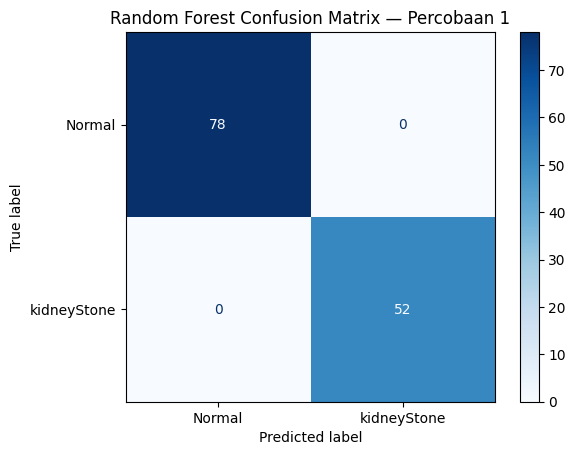

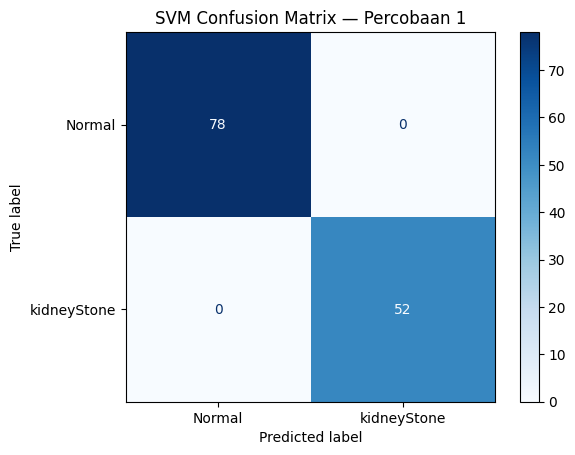

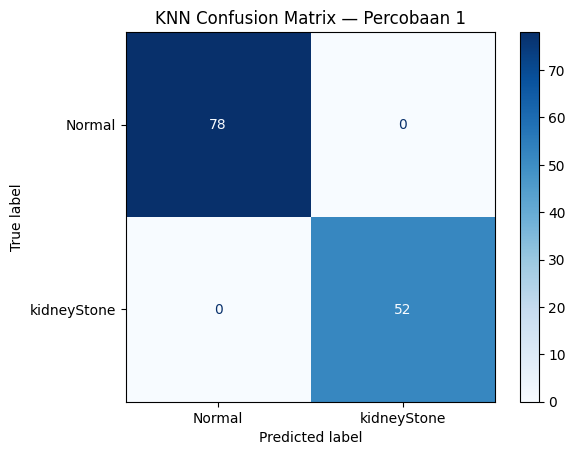

In [17]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 1')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 1')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 1')

## Ringkasan Hasil Percobaan 1

### Fungsi

Cell ini menampilkan ringkasan hasil eksperimen pada preprocessing pertama, meliputi metode preprocessing yang digunakan, jumlah fitur hasil seleksi, serta performa masing-masing algoritma klasifikasi pada data testing.

Ringkasan ini bertujuan untuk mempermudah proses evaluasi dan perbandingan antar percobaan preprocessing yang dilakukan dalam penelitian.

### Hasil Percobaan

**Metode Preprocessing:**
- Resize (256×256)
- Grayscale

**Jumlah fitur setelah seleksi:**
- 10 fitur

**Akurasi Data Testing:**

| Algoritma | Accuracy |
|------------|------------|
| Random Forest | 100% |
| SVM | 100% |
| KNN | 100% |

### Analisis

Berdasarkan hasil pengujian, seluruh algoritma klasifikasi berhasil mencapai nilai Accuracy sebesar 100% pada data testing.

Hasil ini menunjukkan bahwa preprocessing sederhana berupa Resize dan Grayscale sudah mampu menghasilkan fitur tekstur GLCM yang sangat representatif dalam membedakan citra ginjal Normal dan Kidney Stone.

Meskipun tidak menggunakan teknik peningkatan kualitas citra seperti Median Filter, Histogram Equalization, CLAHE, maupun Thresholding, karakteristik tekstur yang terdapat pada citra masih dapat ditangkap dengan baik oleh fitur GLCM. Hal ini menyebabkan ketiga algoritma mampu memisahkan kedua kelas secara sempurna.

Jumlah fitur yang digunakan setelah proses seleksi adalah 10 fitur. Fitur-fitur tersebut telah mampu merepresentasikan informasi tekstur yang relevan sehingga tidak ditemukan kesalahan klasifikasi pada data testing.

Karena Random Forest, SVM, dan KNN menghasilkan performa yang sama, tidak terdapat algoritma yang secara signifikan lebih unggul pada percobaan pertama. Dengan demikian, hasil ini menunjukkan bahwa kualitas fitur yang dihasilkan memiliki pengaruh yang sangat besar terhadap keberhasilan proses klasifikasi.

Ringkasan hasil percobaan pertama ini selanjutnya digunakan sebagai dasar perbandingan dengan preprocessing lainnya untuk mengetahui apakah penambahan teknik peningkatan kualitas citra dapat memberikan peningkatan performa maupun efisiensi jumlah fitur yang digunakan.

In [18]:
print('=== RINGKASAN HASIL PERCOBAAN 1 ===')
print(f'Preprocessing: Resize (256x256) + Grayscale')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 1 ===
Preprocessing: Resize (256x256) + Grayscale
Jumlah Fitur Setelah Seleksi: 10

Akurasi Testing Set:
  Random Forest : 1.0000
  SVM           : 1.0000
  KNN           : 1.0000
